<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

## Abstract

This project aims to develop a predictive model capable of estimating car prices based on their characteristics, using the Cars 4 You dataset. The goal is to support the company’s evaluation process by introducing an automated solution that accelerates car assessments and improves overall efficiency.

The current phase of the project focuses on data exploration, including the identification of data quality issues, such as missing values, inconsistent string formats, and incorrect data types. A preliminary exploratory analysis was performed to understand the structure of the dataset, assess the relationships between features, and identify potential features influencing the car price.


## Import Libraries

The following libraries will help us develop the analyses and model for this project. Pandas and Numpy, provide the efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Scikit-learn offers a range of Machine Learning tools for model training, spliting the data and evaluate model performance. Finally, os, math and ceil are imported to support file management and mathematical operations.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil
import math

# For data manipulation and construction of a dataframe with different lists
import itertools 
from itertools import zip_longest

## Load the dataset
import os

# Set random seed for reproducibility
np.random.seed(40111) 

## Create Meta Data

Understanding the features helps interpret the data correctly and supports subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



## Import Dataset

Here, we are importing with pd.read_csv() the files to start our project and converting them into Pandas DataFrames. CarID was set to index since it's the unique identifier in all data sets.

In [2]:
sample = pd.read_csv('../data/sample_submission.csv')
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

# EDA (Exploratory Data Analysis)

In this phase, we will explore the dataset to identify inconsistencies, missing values, duplicated values and potential relationships and patterns. This analysis will be very helpfull for the Preprocessing stage where we'll need to correct all these issues to improve the overall performance of our model.

### Define new index for our datasets

In [3]:
sample.set_index('carID', inplace = True)
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

### Sample

In this first analysis, we look at the sample dataset given by the professor. This dataset includes the target feature, which shows how our final results should look.

In [4]:
print("Initial Analysis of the Sample Submission Dataset")
print('')
print(sample.shape)
print('-----------------------')
print(sample.head())
print('-----------------------')
print(sample.tail())

Initial Analysis of the Sample Submission Dataset

(32567, 1)
-----------------------
         price
carID         
89856   851000
106581  514000
80886   323000
100174  921000
81376   620000
-----------------------
         price
carID         
105775  412000
81363   441000
76833   684000
91768   835000
99627     2000


In [5]:
print("Continue to analyse the Sample Submission Dataset")
print('------------------------')
print('')
print(sample.info()) #From this output we can see that this dataset hasn't missing values
print('')
print('------------------------')
print(sample.describe())

Continue to analyse the Sample Submission Dataset
------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 32567 entries, 89856 to 99627
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   price   32567 non-null  int64
dtypes: int64(1)
memory usage: 508.9 KB
None

------------------------
               price
count   32567.000000
mean   498198.943716
std    288111.809635
min      1000.000000
25%    249000.000000
50%    501000.000000
75%    746000.000000
max    999000.000000


## Initial Analysis Train/Test

In this section, we perform an initial exploration of the train and test datasets to understand their basic structure and content. We examine the first and last rows of the data, check general information about features, and review summary statistics. This helps us get a first overview and detect any immediate issues before deeper analysis.

In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
#Here we can see that the test shape is equal to the sample shape.

Train shape: (75973, 13)
Test shape: (32567, 12)


In [7]:
train.head(10)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.000000,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.000000,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.000000,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.000000,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.000000,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
14704,BMW,3 Series,2014.0,8199,anual,101153.348285,Diesel,30.0,65.700000,2.0,74.0,0.000000,0.0
6924,Audi,A3,2017.0,16089,Manual,21396.000000,Petrol,20.0,60.100000,1.4,75.0,4.000000,0.0
50783,Skoda,Octavia,2017.0,7500,Manual,116750.000000,Diesel,145.0,68.900000,1.6,59.0,4.000000,0.0
67071,VW,Passat,2017.0,15999,Semi-Auto,30339.000000,Diesel,150.0,62.800000,2.0,85.0,4.000000,0.0


In [8]:
train.tail(10)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
67221,VW,T-Roc,2020.0,25785,Semi-Auto,10.0,Petrol,145.0,39.80000,1.5,65.0,4.0,0.0
41090,Mercedes,GLC Class,2016.0,24486,NaN,22955.0,Diesel,125.0,56.50000,2.1,72.0,4.0,0.0
16023,Ford,EcoSport,2017.0,10498,Manual,13613.0,Petrol,125.0,88.32164,1.0,57.0,3.0,0.0
60263,Opel,Crossland X,2018.0,13995,Manual,1800.0,Petrol,150.0,57.70000,1.2,69.0,0.0,0.0
44131,Mercedes,GLC Class,2018.0,30495,Semi-Auto,11943.0,Diesel,150.0,56.50000,2.1,74.0,NaN,0.0
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.30000,2.0,78.0,0.0,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.90000,2.0,38.0,2.0,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.00000,1.0,57.0,3.0,0.0
860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.10000,2.0,74.0,2.0,0.0


From the visualization of the head and tail of the data base we can already understand that some errors exist:

    - Missing values
    - Values in the columns Year, hasDamage, previousOwners that should be integers as floats (2020.0)
    - Floats on mpg, previousOwners column with diferent decimal cases length.
    - It looks like the column hasDamage only contains 0's. It's probably a boolean.
    - Negative values in columns that shouldn't have, per example in previousOwners column.
We will further analyse this using describe and info.

It's also possible to see that some strings have the same information written in different forms (Petrol as etrol).
To solve this problem we will uniformize all the values in data preparation

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75973 entries, 69512 to 15795
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           74452 non-null  object 
 1   model           74456 non-null  object 
 2   year            74482 non-null  float64
 3   price           75973 non-null  int64  
 4   transmission    74451 non-null  object 
 5   mileage         74510 non-null  float64
 6   fuelType        74462 non-null  object 
 7   tax             68069 non-null  float64
 8   mpg             68047 non-null  float64
 9   engineSize      74457 non-null  float64
 10  paintQuality%   74449 non-null  float64
 11  previousOwners  74423 non-null  float64
 12  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 8.1+ MB


From info we can see that:

    - the year values as floats is impossible.
    - The previousOwners, hasDamage also as floats but they should be integers and booleans respectively.
    - Missing values in all features except the price.

What will we do?

    Analyse with describe to have a different view

In [10]:
train.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


From the numeric describe we can see that we have some weird values:

    1. negative mileage, tax, mpg, engineSize, previousOwners in the minimum value
    2. hasDamage is a boolean but we can see that instead of 0 and 1 we only have 0 and Nones*
    3. previousOwner has a float? Should we round it?

*check in the hasDamage column

What will we do:

    1. Count the number of negative values and decide if we should drop or change them.
    2. Replace the nones by 1's. (data-preparation)
    3. Count the number of float values and decide to drop or round them.

In [11]:
train.describe(include='object').T

,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


From the categorical describe, we can see that some columns contain missing values, indicating incomplete data that may need to be addressed before modeling. Additionally, we can observe the number of unique categories in each column, as well as the most frequent category and its frequency. This information gives us an initial understanding of the distribution and variability of the categorical features, which can help guide preprocessing decisions such as encoding or handling rare categories.


### **Missing Values**

In this part, we examine the dataset to identify any missing values in the features. Understanding where data is missing helps us plan how to handle it, whether through imputation, removal, or other preprocessing steps, ensuring the dataset is suitable for modeling.

In [12]:
# Number of rows in the dataset
rows_number = train.shape[0]

# Number of missing values per column
missing_counts = train.isnull().sum()

# Percentage of missing values per column
missing_percentage = (missing_counts / rows_number) * 100

# Show in DataFrame format, sorted from highest to lowest
missing_df = missing_percentage.sort_values(ascending=False).reset_index()
missing_df.columns = ['Feature', 'Missing_Percent']

print(missing_df)

           Feature  Missing_Percent
0              mpg        10.432654
1              tax        10.403696
2   previousOwners         2.040198
3        hasDamage         2.037566
4    paintQuality%         2.005976
5     transmission         2.003343
6            Brand         2.002027
7            model         1.996762
8       engineSize         1.995446
9         fuelType         1.988864
10            year         1.962539
11         mileage         1.925684
12           price         0.000000


Although some features have missing values, the percentage of missing data is relatively low across all columns. This information highlights which features may require attention during preprocessing.

After this analysis, we decided to save this information in a separate DataFrame to use later during preprocessing. This allows us to have a clear reference of incomplete data and helps streamline the cleaning and imputation process.

In [13]:
# Go one level up from the notebooks folder to reach the repo root
processed_dir = "../EDA_outputs"
os.makedirs(processed_dir, exist_ok=True)

# Save the missing values summary to a CSV file
missing_df.to_csv(f"{processed_dir}/missing_values_summary.csv", index=True)

### **Duplicates**

Here, we check for duplicate entries in the dataset. Detecting and removing duplicates is important to prevent bias and ensure that each observation contributes uniquely to the analysis and model training.

In [14]:
print(f"The duplicates without the index is: {train.duplicated().sum()}") 
print(f"The percentages of duplicates is: {(train.duplicated().sum()/len(train) * 100).round(4)}%")

The duplicates without the index is: 4
The percentages of duplicates is: 0.0053%


It's also important to check for duplicates in the index, because assign the feature carID as our index.

In [15]:
print(f"The duplicates in carID (defined as index) is: {train.index.has_duplicates}")

The duplicates in carID (defined as index) is: False


From the code above, we can conclude that there are four entries with duplicated values but different IDs. Since the percentage of duplicates in the dataset is 0.0053% and there are 0% duplicates in the index, we decided to remove the duplicate records found in the dataset.

In [16]:
train = train.drop_duplicates()

## Univariate Analysis

In this section, we analyze each feature individually to understand its distribution and main characteristics. This helps us identify patterns, outliers, and possible data quality issues within each feature.

### Unique Values

We examine the number of unique values in each feature. This helps us understand the diversity of the data, identify categorical features, and detect features with little or no variability that may be less informative for modeling.

In [17]:
for column in train.columns:
    unique_values = train[column].unique()
    print(f"Unique values on the column '{column}': {unique_values}")
    print('-----------------------------------')
    print('')


Unique values on the column 'Brand': ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
-----------------------------------

Unique values on the column 'model': [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' E

Comments on the results above for each feature:
- `Brand` have significant inconsistencies with case sensitivity, ('mercede', 'FOR'), and fragmented entries ('pel', 'udi').

- `Model` have a lot of variations due to leading/trailing spaces, inconsistent casing, typos ('Focu' instead of 'Focus'), and incomplete entries ('A Clas').

- `Year` have decimal/fractional values (e.g., 2023.36707842) suggests data encoding errors or floating-point artifacts. 

- `Price` have numeric and diverse.

- `Transmission` column with multiple variants and typos exist for common types (e.g., 'Manual', 'manua', 'anual'). Also we noticed that in this columns there are 'Unknown' values.

- `Mileage` appears mostly clean and numeric.

- `FuelType` have many spelling and case variations (e.g., 'Petrol', 'petrol', 'etrol') exist.

- `Tax` with negative and fractional values are suspicious. 

- `MPG` looks like contain outliers and invalid negative values.

- `EngineSize` includes some unusual negative and zero values that should be verified.

- `PaintQuality%` have some values greater than 100%, what is not possible.

- `PreviousOwners` contains unexpected negative/fractional values and NaNs.

- `HasDamage` is Binary flag with values 0 and NaN.

### Count Values

Here, we analyze the frequency of each value in the categorical features. Studying value counts allows us to see which categories are most common, identify imbalanced distributions, and detect rare or unusual values that may require special handling during preprocessing.

In [18]:
for column in train.select_dtypes(include=['number']).columns:
    count_values = train[column].value_counts()
    print(f"The number of the distinct values in the column '{column}' is: {count_values}")
    print('-----------------------------------')
    print('')

The number of the distinct values in the column 'year' is: year
2019.000000    20270
2017.000000    16144
2016.000000    11502
2018.000000    10303
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2011.111188       15
2001.000000       15
2022.878006       12
2000.000000        6
1998.000000        5
1999.000000        5
1970.000000        2
1997.000000        2
1996.000000        1
Name: count,

Most of all the comments that can be done from the results above were already done after the .unique() analysis. 
With both this analysis we are planning to do the following for each feature:

- `Brand`, `Model`, `Transmission` and `FuelType`: unify capitalization, spacing and correct spelling errors and inconsistent spellings.

- `Year`: convert all values to integers and fix or remove non-sensical decimal values.

- `Price`: drop from the dataset and assign to a target feature.

- `Mileage`, `Tax`, `MPG`, `EngineSize` and `PreviousOwners`: ensure values are numeric and postive, detect and handle unrealistic or extreme values (e.g., negative, float or abnormall values in the feature context).

- `PaintQuality%`: cap values between 0 and 100.

- `HasDamage`: maybe assign the nan values to 1 cause we only have 0's and this should be a boolean feature.

Besides all this notes we need also to consider all the missing value noticed before on the DataFrame.


### Categories Frequency

Here we examine the categorical features in the dataset by computing their frequency distributions. This allows us to identify the most common categories, detect rare or unbalanced classes, and better understand the overall composition of each feature. 

In [19]:
for column in train.select_dtypes(include=['object']).columns:
    vc = train[column].value_counts(dropna=False)
    print(f"--- {column} (n_unique={vc.shape[0]}) ---")
    display(vc.head(10))


--- Brand (n_unique=73) ---


Brand
Ford        14806
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
Audi         6749
Toyota       4289
Skoda        3973
Hyundai      3064
NaN          1521
Name: count, dtype: int64

--- model (n_unique=736) ---


model
 Focus       6351
 C Class     4886
 Fiesta      4130
 Golf        3081
 Corsa       2182
 Polo        2046
 Astra       1744
 A Class     1618
 3 Series    1566
NaN          1517
Name: count, dtype: int64

--- transmission (n_unique=41) ---


transmission
Manual       38048
Semi-Auto    15545
Automatic    14001
NaN           1522
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Name: count, dtype: int64

--- fuelType (n_unique=35) ---


fuelType
Petrol    37992
Diesel    28474
Hybrid     2042
NaN        1511
PETROL      795
etrol       794
Petro       785
petrol      746
iesel       603
diesel      599
Name: count, dtype: int64

### Target feature (Price)

In this subsection, we explore the characteristics of the target feature, Price. Since price exhibit a right-skewed distribution with a wide range of values, we also analyze the logarithm of Price (log(Price)). Using the logarithmic transformation helps stabilize variance, reduce the influence of extreme values, and allows for a more interpretable analysis in terms of relative or percentage changes rather than absolute differences. This approach is particularly useful for modeling and understanding economic or financial features that typically follow multiplicative patterns.

Price skew: 2.284
Log(price) skew: -0.144


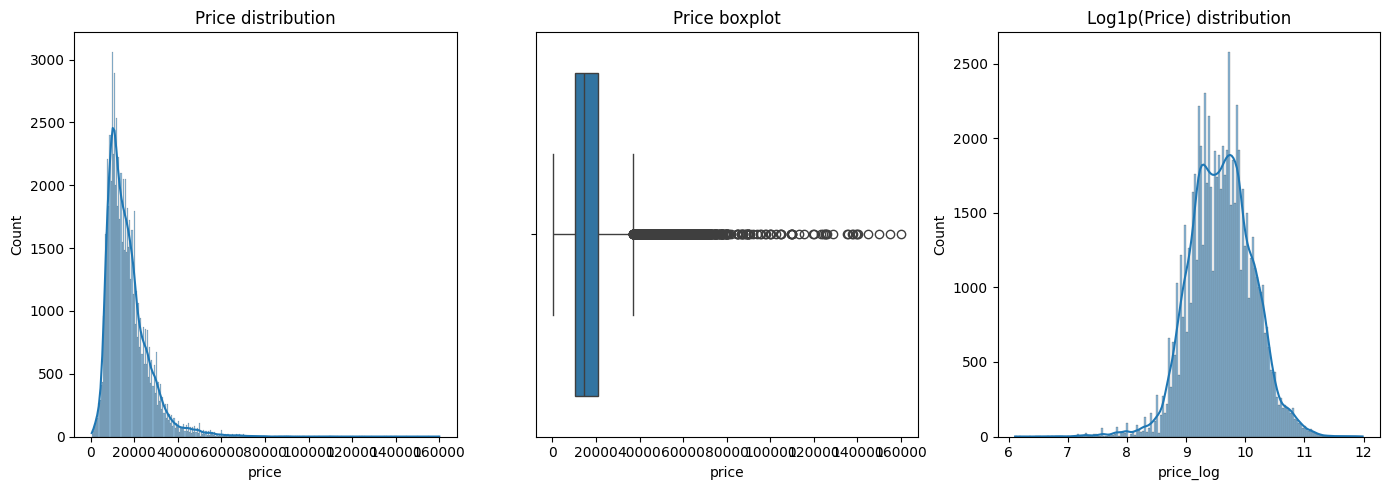

In [20]:
# Distribution & Transform
train['price_log'] = np.log1p(train['price'])

# Statistics
# Calculate skewness, which measures how asymmetric the data distribution is
print("Price skew:", train['price'].skew().round(3)) 
print("Log(price) skew:", train['price_log'].skew().round(3))

# Plots
fig, axes = plt.subplots(1,3, figsize=(14,5))
sns.histplot(train['price'], ax=axes[0], kde=True)

axes[0].set_title('Price distribution')
sns.boxplot(x=train['price'], ax=axes[1])
axes[1].set_title('Price boxplot')

# Also plot log-price
sns.histplot(train['price_log'], ax=axes[2], kde=True)
axes[2].set_title('Log1p(Price) distribution')

plt.tight_layout()
plt.show()

The distribution of Price is highly right-skewed, with most observations concentrated at lower values and a long tail of high prices, as shown in both the histogram and boxplot. This indicates the presence of several extreme values (outliers) and a non-normal distribution, which could negatively affect modeling performance if used directly.

With the application the logarithmic transformation, the distribution becomes much more symmetric and closer to a normal shape. This transformation reduces the impact of extreme values, stabilizes the variance, and facilitates the use of linear models and other statistical methods that assume normality. Additionally, it allows for interpreting model results in terms of percentage changes rather than absolute price differences, which is more meaningful in most economic and financial contexts.

In [21]:
cat_cols = train.select_dtypes(include=['object','category']).columns.tolist()
for c in cat_cols:
    vc = train[c].value_counts(dropna=False)
    print(f"--- {c} (n_unique={vc.shape[0]}) ---")
    display(vc.head(10))

--- Brand (n_unique=73) ---


Brand
Ford        14806
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
Audi         6749
Toyota       4289
Skoda        3973
Hyundai      3064
NaN          1521
Name: count, dtype: int64

--- model (n_unique=736) ---


model
 Focus       6351
 C Class     4886
 Fiesta      4130
 Golf        3081
 Corsa       2182
 Polo        2046
 Astra       1744
 A Class     1618
 3 Series    1566
NaN          1517
Name: count, dtype: int64

--- transmission (n_unique=41) ---


transmission
Manual       38048
Semi-Auto    15545
Automatic    14001
NaN           1522
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Name: count, dtype: int64

--- fuelType (n_unique=35) ---


fuelType
Petrol    37992
Diesel    28474
Hybrid     2042
NaN        1511
PETROL      795
etrol       794
Petro       785
petrol      746
iesel       603
diesel      599
Name: count, dtype: int64

### Descriptive Statistics and Visualizations

This section starts by split our data in metric, discrete and continuous, and non-metric features and after that we summarize the main characteristics of the dataset using descriptive statistics and visualizations. This helps us understand distributions, trends, and potential anomalies, providing insights that guide further analysis and modeling decisions.

In [22]:
train

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price_log
carID,,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0,10.011938
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0,9.531771
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0,10.126271
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0,9.433564
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0,10.043076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0,9.510371
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0,9.433164
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0,9.035987


In [23]:
train

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price_log
carID,,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0,10.011938
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0,9.531771
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0,10.126271
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0,9.433564
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0,10.043076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0,9.510371
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0,9.433164
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0,9.035987


In [24]:
# Separate the features
metric_features = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
non_metric_features = train.drop(columns=metric_features).columns.tolist()

continuous_features = ['price', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']
discrete_features = ['year', 'previousOwners', 'paintQuality%']

# Organize the new lists in a table to better visualize them
data = list(zip_longest(
    metric_features,
    non_metric_features,
    continuous_features,
    discrete_features,
    fillvalue=""
))

headers = [
    "Metric Features",
    "Non-Metric Features",
    "Continuous Features",
    "Discrete Features"
]

df_table = pd.DataFrame(data, columns=headers)
print(df_table.to_string(index=False))


Metric Features Non-Metric Features Continuous Features Discrete Features
           year               Brand               price              year
          price               model             mileage    previousOwners
        mileage        transmission                 tax     paintQuality%
            tax            fuelType                 mpg                  
            mpg           hasDamage          engineSize                  
     engineSize           price_log       paintQuality%                  
  paintQuality%                                                          
 previousOwners                                                          


#### **Histograms**

Are used to examine the distribution of continuous features. Histograms help us see the shape of the data, detect skewness, and identify potential outliers or patterns in the feature values.

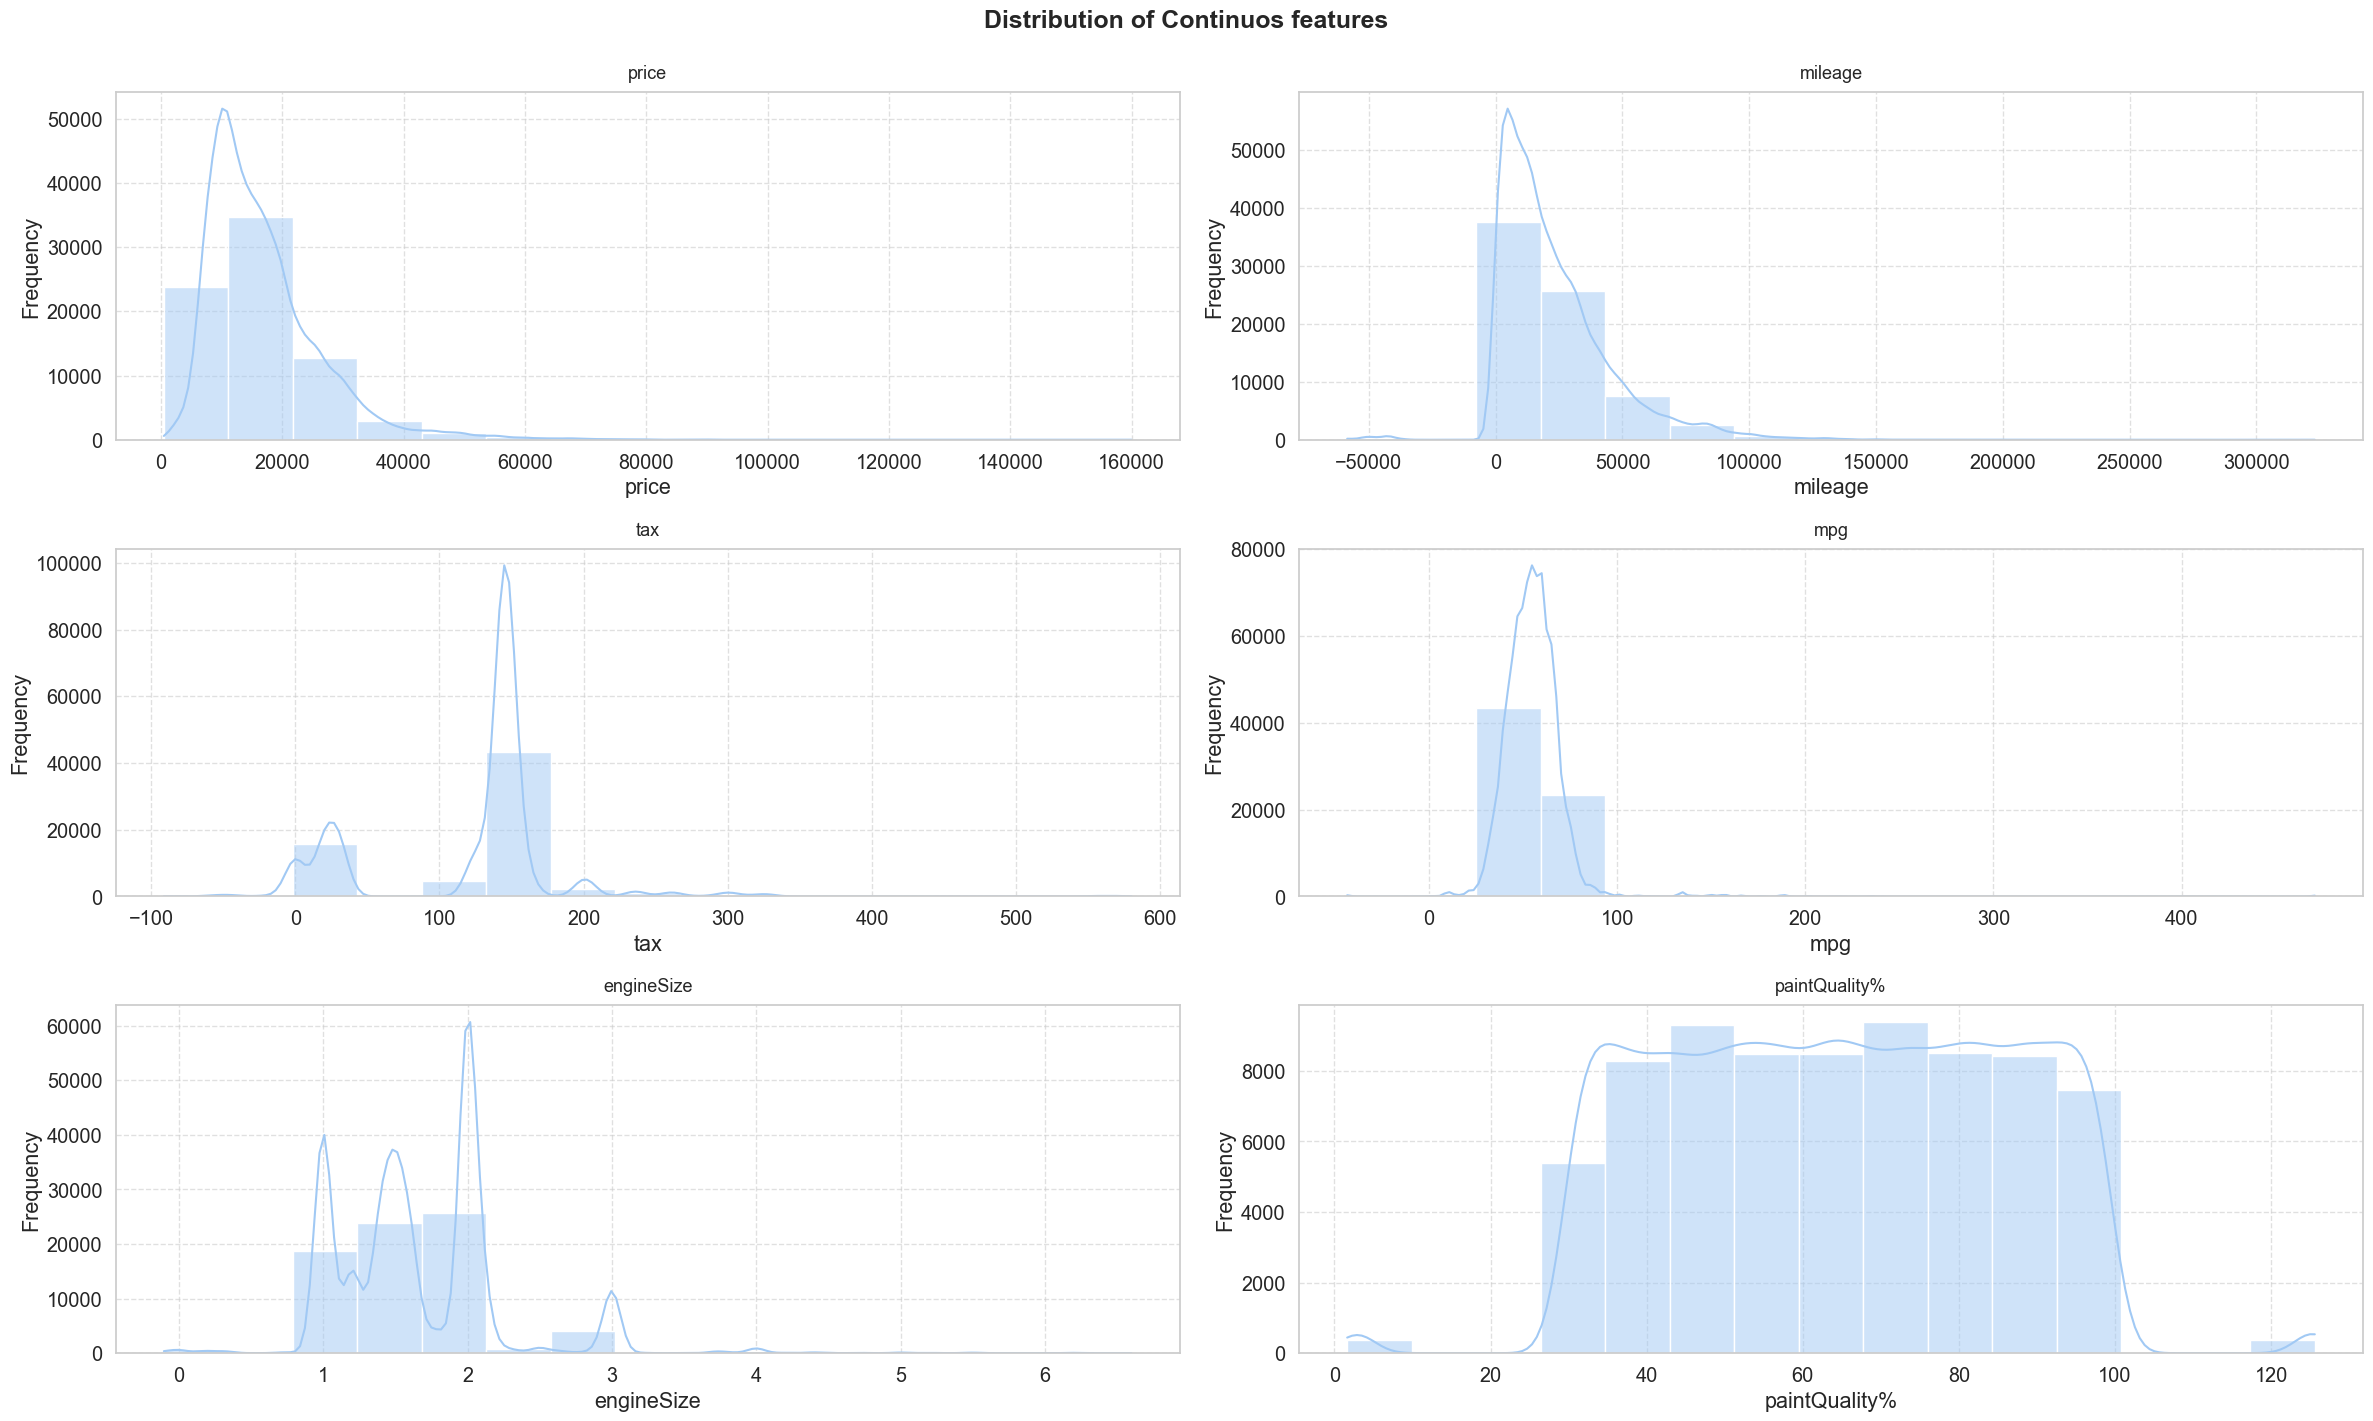

In [25]:
# General settings
sns.set(style="whitegrid", palette="pastel", font_scale=1.3)

sp_rows, sp_cols = 3, 2
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(24, 15))

# Plot data
# Iterate across axes objects and associate each histogram
for ax, feat in zip(axes.flatten(), continuous_features):
    kde_flag = True
    sns.histplot(data=train, x=feat, bins=15, kde=kde_flag, ax=ax)
    ax.set_title(feat, fontsize=13, pad=10)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.6)

# General Layout
fig.suptitle("Distribution of Continuos features", fontsize=18, fontweight='bold', y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


With the evaluation of the histograms we can affirmate that:

`Price` - The distribution is strongly right-skewed, most cars are low or mid-priced, but a few luxury vehicles inflate the tail. Some prices are extreme outliers, possibly due to rare high-end models. From here we can say that the market is dominated by affordable vehicles.

`Mileage` - Also right-skewed, which is expected. Most used cars have moderate mileage, and a few have very high values. The histogram shows again negative values.

`Tax` - Sharp peak around a specific value (≈150–200), indicating standardized taxation rates for most vehicles. Some negative or zero values are also noticed.

`Mpg` - Distribution shows that most cars cluster around 20 to 90 mileage per gallon , with few very high or very low values, the negatives values being incorrect.

`EngineSize` - Multiple peaks, possibly due to different engine categories (1.0L, 1.5L, 2.0L, etc.). The pattern may reflect distinct market segments.

`PaintQuality%` - Fairly uniform distribution across mid-to-high values (40–100%), indicating most vehicles have decent paint condition. We can see a few very low or very high values that are outliers. The highest outliers are incorrect values because this column should have values between 0 and 100 since it's a percentage. 

#### **BarPlots**

Are used to examine the distribution of discrete features. These graphs, also help us see the shape of the data, detect skewness, and identify potential outliers or patterns in the feature values.

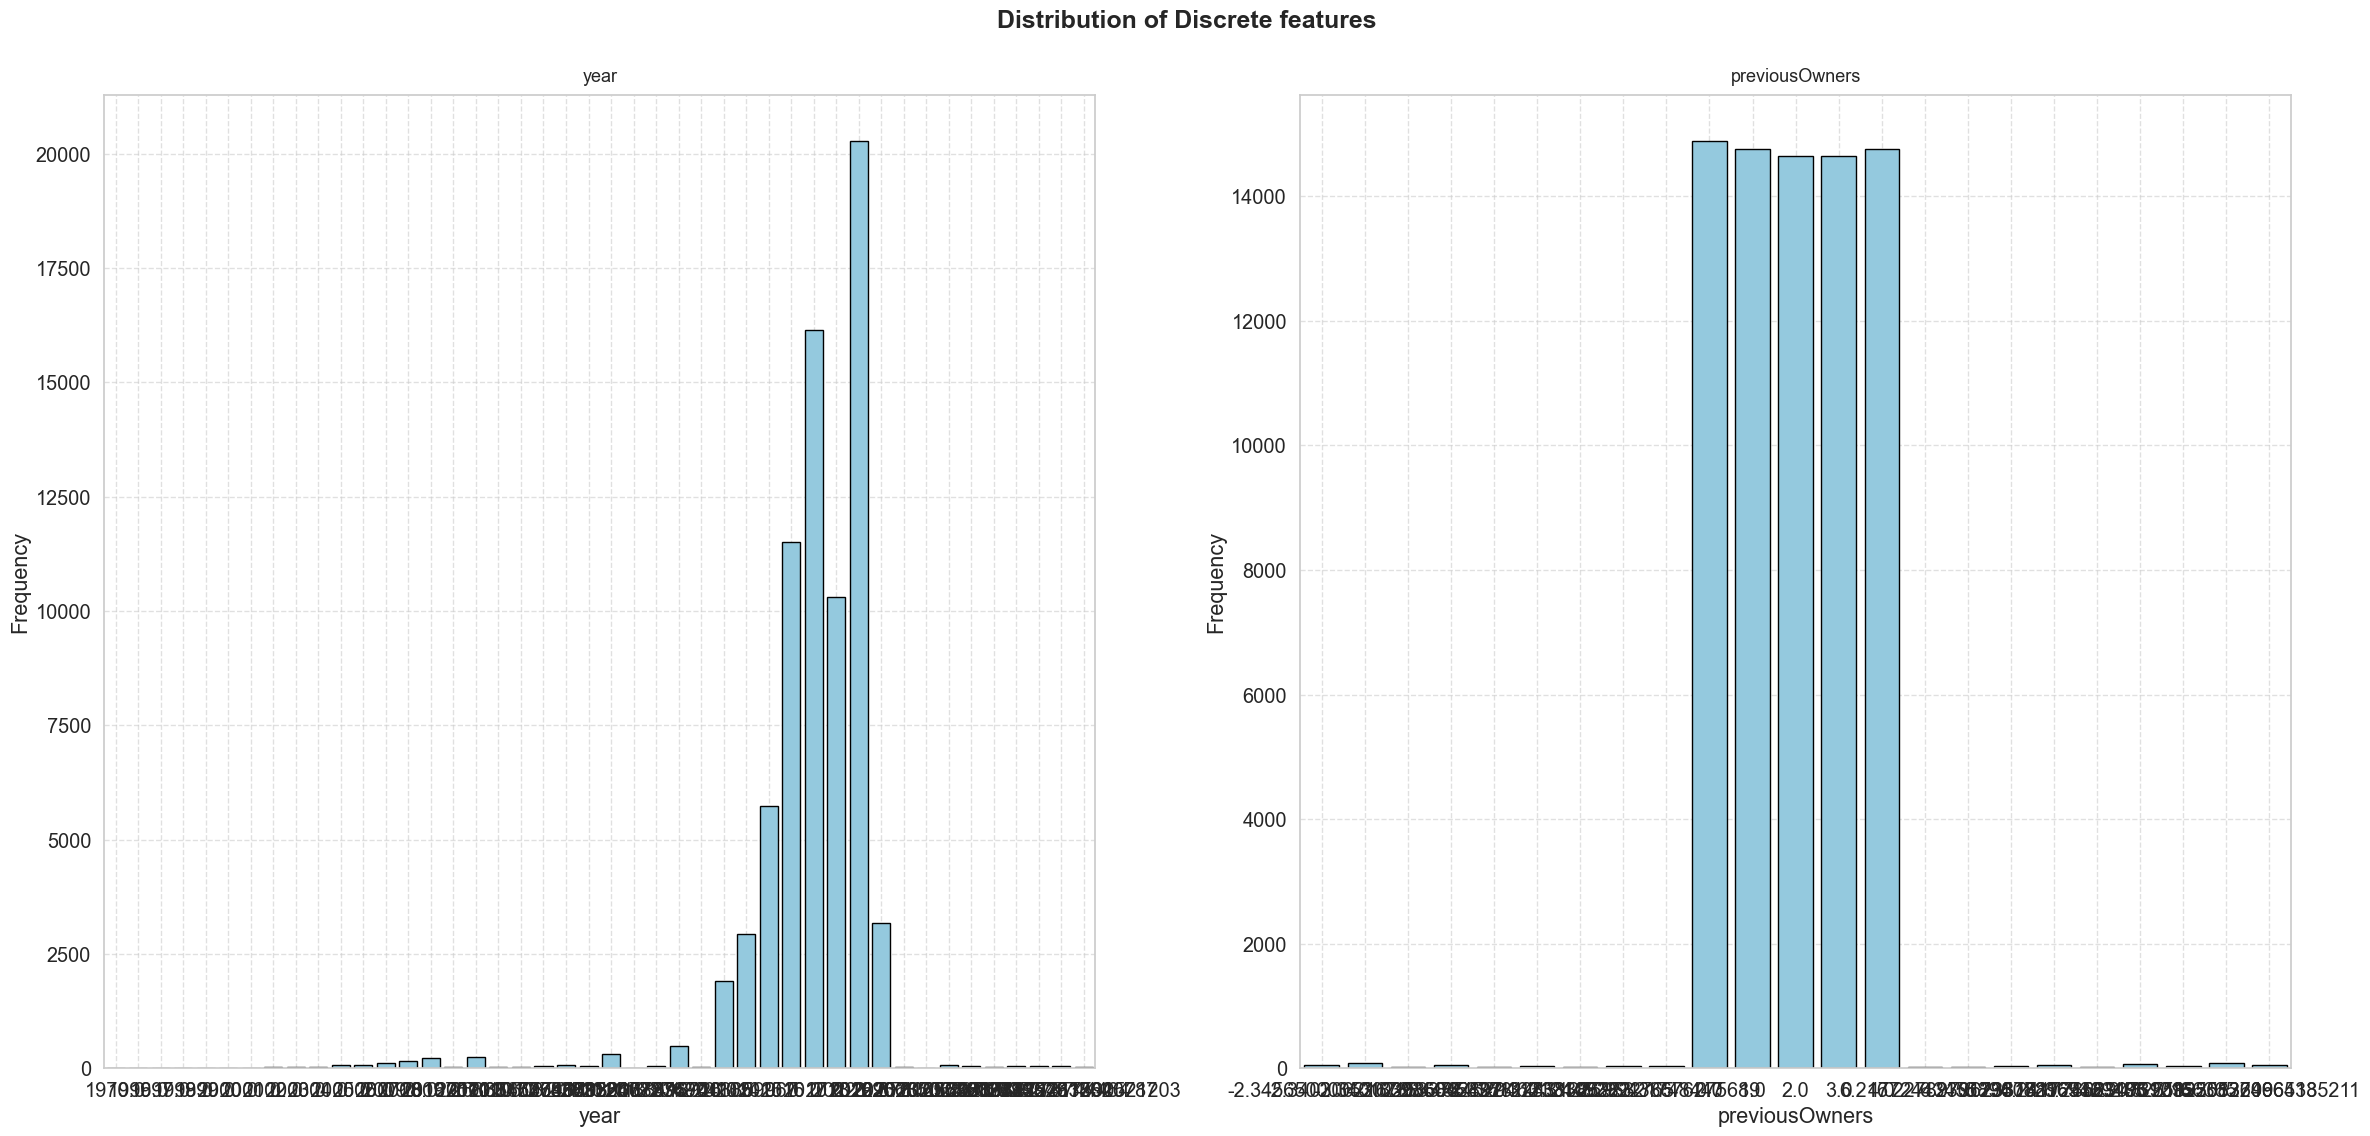

In [26]:
# General settings
sns.set(style="whitegrid", palette="pastel", font_scale=1.3)

sp_rows, sp_cols = 1, 2
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(24, 12))

# Plot data
for ax, feat in zip(axes.flatten(), discrete_features):
    sns.countplot(data=train, x=feat, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f"{feat}", fontsize=13, pad=10)
    ax.set_ylabel("Frequency")
    ax.set_xlabel(feat)
    ax.grid(True, linestyle="--", alpha=0.6)

fig.suptitle("Distribution of Discrete features", fontsize=18, fontweight='bold', y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


#### **Boxplots** (Outliers Detection)

Are used to visualize the spread and variability of numerical features. Boxplots highlight the median, quartiles, and outliers, making it easier to detect unusual values and understand the overall data distribution.

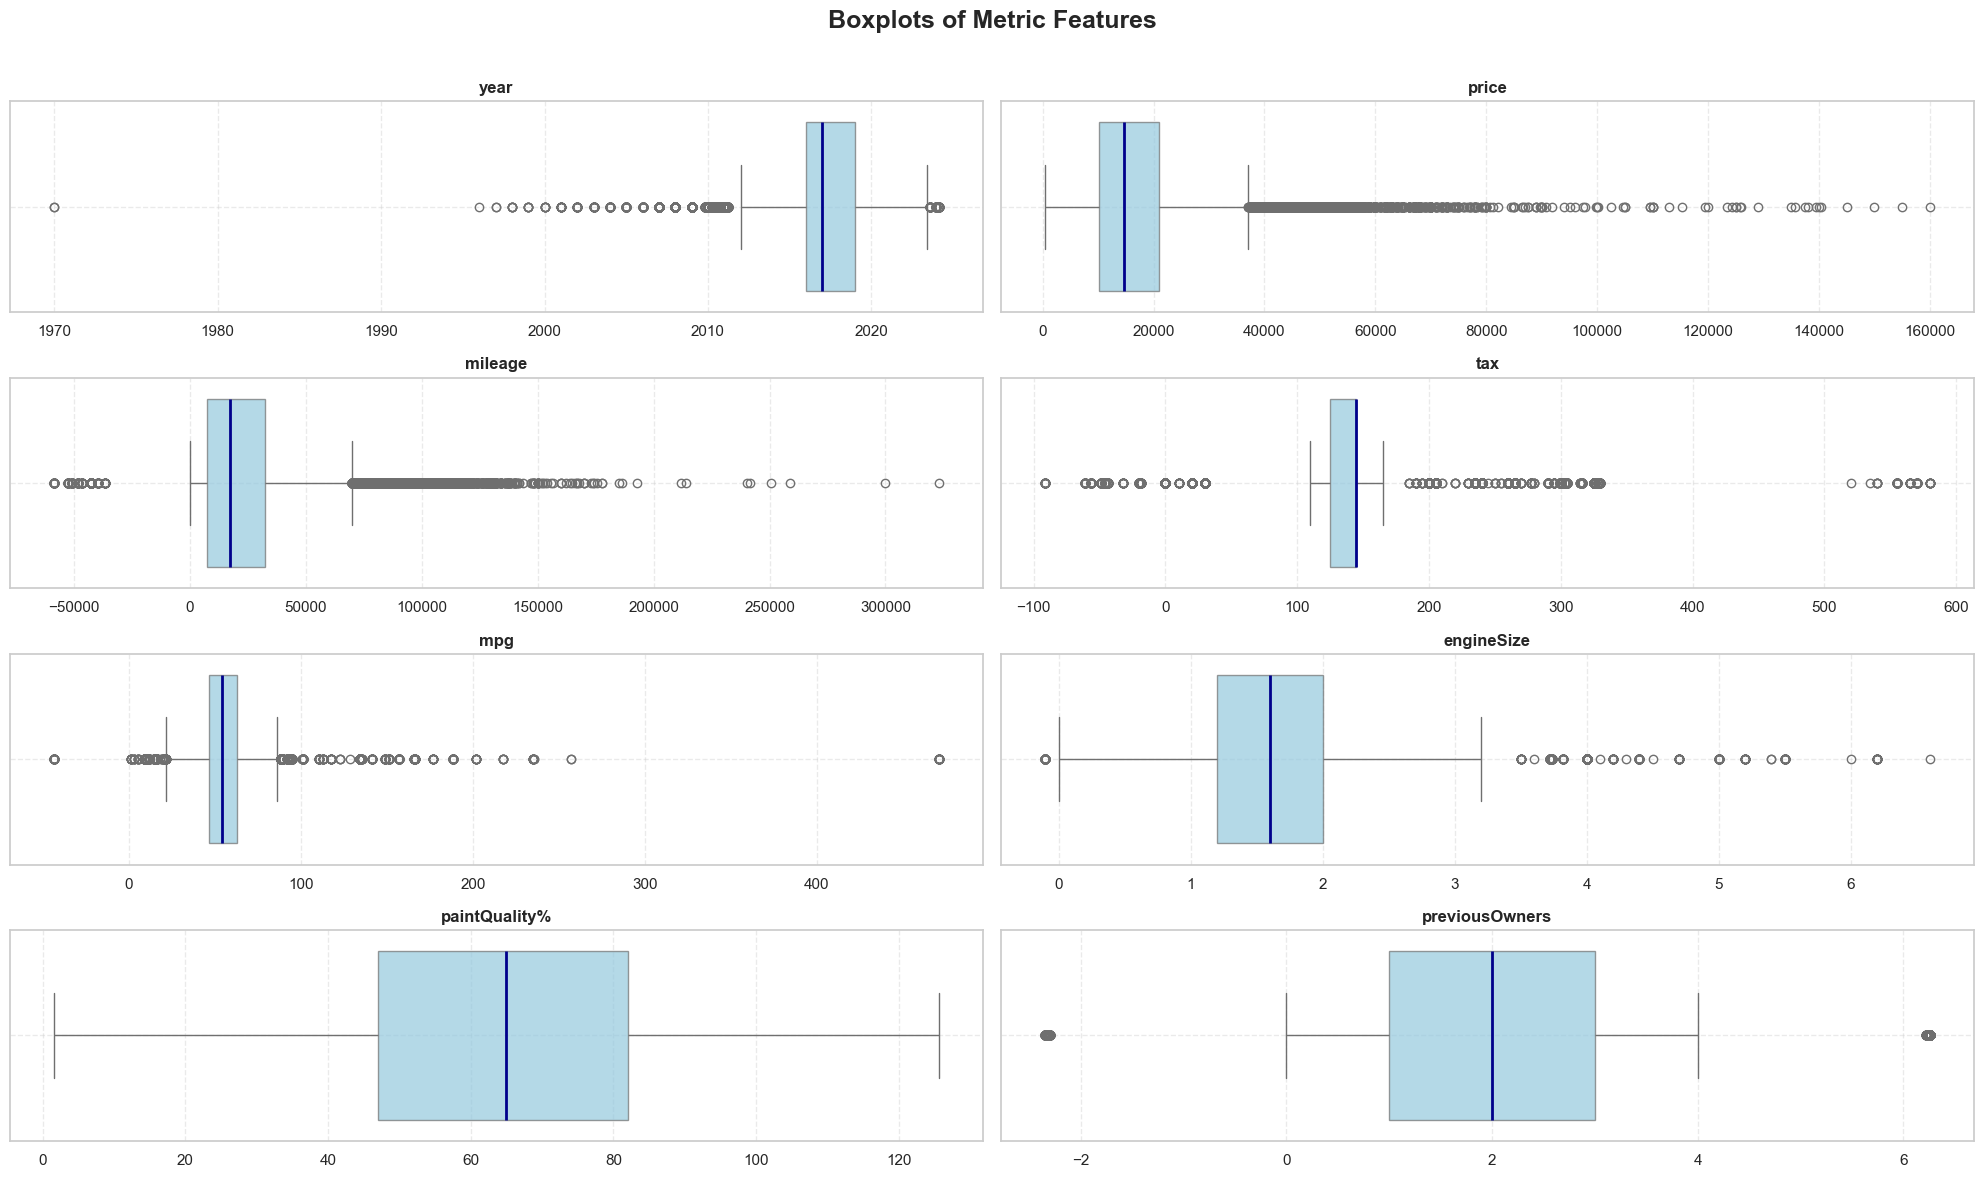

In [27]:
# Style settings
sns.set_theme(style="whitegrid", palette="pastel")

# Prepare figure with appropriate number of rows and columns
n_features = len(metric_features)
n_cols = 2  
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

# Plot boxplots
for i, feat in enumerate(metric_features):
    ax = axes[i]

    # Boxplot with highlighted median line
    sns.boxplot(
        x=train[metric_features][feat],
        ax=ax,
        color='skyblue',
        medianprops={"color": "darkblue", "linewidth": 2},
        boxprops={"alpha": 0.7}
    )
    
    ax.set_title(f"{feat}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")  # Remove automatic x-label
    ax.grid(True, linestyle="--", alpha=0.4)

# Remove empty axes (if the number of features is not a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# General title and layout
plt.suptitle("Boxplots of Metric Features", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Based on the boxplots shown above, it can be observed that:

`Price`- This boxplot is right-skewed, with a large proportion of outliers ranging approximately from £40,000 up to £160,000, showing a wide interval compared to the main body of the data.

`Mileage` - Mileage displays a positively skewed distribution with several high-value outliers and a negative value appears in the data.

`Tax`- The distribution is concentrated around specific values but includes some outliers.

`Mpg`- The distribution is mostly concentrated but includes both low and very high outliers. Some extreme values, such us those above 200 mpg are unrealistic and will be validated.

`EngineSize`- The boxplot shows most engines concentrated between 1.0 and 2.0L, with several larger values appearing as outliers.

`PaintQuality%`- This boxplot shows few distinct values spread across a wide range, with numeric codes representing quality levels.

`PreviousOwners`- The distribution is concentrated between 1 and 3 owners, with a few outliers, including cars with more than 6 owners and some negative values.

`Year` - The distribution is left-skewed, with a wide range of outliers from the middle 1990's until early 2000's.

## Bivariate Analysis

Here we study the relationship between two features at a time, mainly between the features and the target feature. This analysis helps us understand how each feature might influence the target and whether any correlations exist.

### GroupBy

We use groupby operations to summarize and compare data across some different categories. This allows us to examine how numerical features vary between groups, identify patterns, and explore relationships that may be important for modeling.

In [28]:
print(train.groupby('hasDamage')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('year')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('previousOwners')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('Brand')['price'].mean())


hasDamage
0.0    16883.327287
Name: price, dtype: float64
--------------------------------------------------------
year
1970.000000    17747.000000
1996.000000     3000.000000
1997.000000     6972.500000
1998.000000    10183.800000
1999.000000     3986.000000
2000.000000     3869.166667
2001.000000     4401.000000
2002.000000     3206.920000
2003.000000     3452.517241
2004.000000     4179.914286
2005.000000     3007.468750
2006.000000     3958.580645
2007.000000     3454.910569
2008.000000     3913.069620
2009.000000     4141.008772
2009.816757    19686.486486
2010.000000     5016.514523
2010.268635    12568.100000
2010.371546    24268.114286
2010.565009    11370.425532
2010.676968    12834.268293
2010.746403    18257.810345
2011.000000     6771.940252
2011.111188    13038.466667
2011.210853    22981.640000
2012.000000     7601.456067
2012.695740    12633.095238
2013.000000     8503.491062
2014.000000    10025.783276
2015.000000    11654.296180
2016.000000    13357.350287
2017.000000 

The mean of price of the cars without damage is approximately 16883. It would be interesting to compare with the one's with damage (1's), but we don't have any information about them.

It's also possible to verify that the price varies depending on the year of manufacture of the cars. This is, the older the car, the cheaper it is.

For the number of previous Owners, we don't see major differences on the average price. 

Finally, when analysing the average price per brand, we can already see some differences between brands, per example, Hyundai's cars have lower average than Audi's cars.


### Correlation Between Features

This section is quite important. We analyze the relationships between numerical features using correlation measures. This helps us identify which featires are strongly related, detect potential multicollinearity, and understand how features may influence each other or the target feature.

In [29]:
numeric_features = train[['year', 'mileage', 'price', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']]
numeric_features.corr(method="pearson").round(3)

,year,mileage,price,tax,mpg,engineSize,paintQuality%,previousOwners
year,1.000,-0.669,0.476,0.179,-0.123,-0.038,0.004,0.000
mileage,-0.669,1.000,-0.405,-0.202,0.167,0.099,-0.001,0.002
price,0.476,-0.405,1.000,0.297,-0.286,0.612,0.000,-0.000
tax,0.179,-0.202,0.297,1.000,-0.419,0.257,0.006,0.003
mpg,-0.123,0.167,-0.286,-0.419,1.000,-0.227,-0.003,-0.001
engineSize,-0.038,0.099,0.612,0.257,-0.227,1.000,0.005,0.001
paintQuality%,0.004,-0.001,0.000,0.006,-0.003,0.005,1.000,-0.006
previousOwners,0.000,0.002,-0.000,0.003,-0.001,0.001,-0.006,1.000


From the code before it's difficult to get conclusions. We will visualize this matrix using a heatmap. The heatmap provides an intuitive overview of the strength and direction of relationships, making it easier to identify strongly correlated features and patterns in the data.

Here we use heatmaps based on Pearson and Spearman correlation coefficients. Pearson correlation measures linear relationships, while Spearman correlation captures monotonic relationships. 

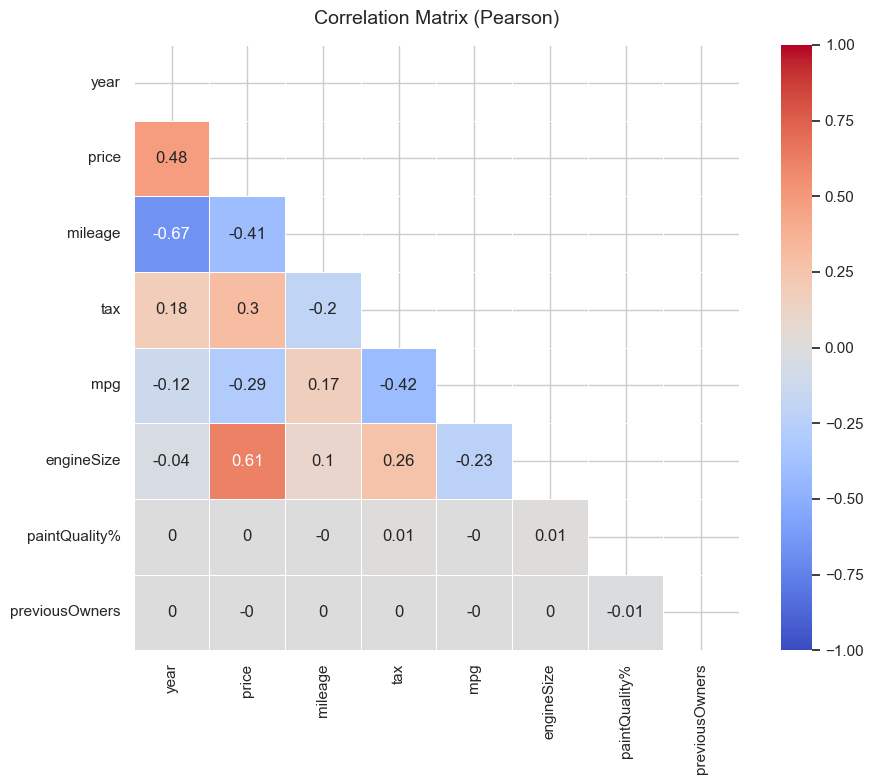

In [30]:
corr = train[metric_features].corr(method="pearson").round(2)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Visualize correlation matrix
fig = plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,                # hide upper triangle
    annot=True,               # show values
    cmap="coolwarm",          # divergent color map
    center=0,                 # center colormap in 0
    linewidths=0.5,           # lines between cells to help visualization
    vmin=-1, vmax=1,          # fix scale
    square=True               # make cells square-shaped
)


plt.title("Correlation Matrix (Pearson)", fontsize=14, pad=15)
plt.tight_layout() # improve layout by reducing overlaps
plt.show()


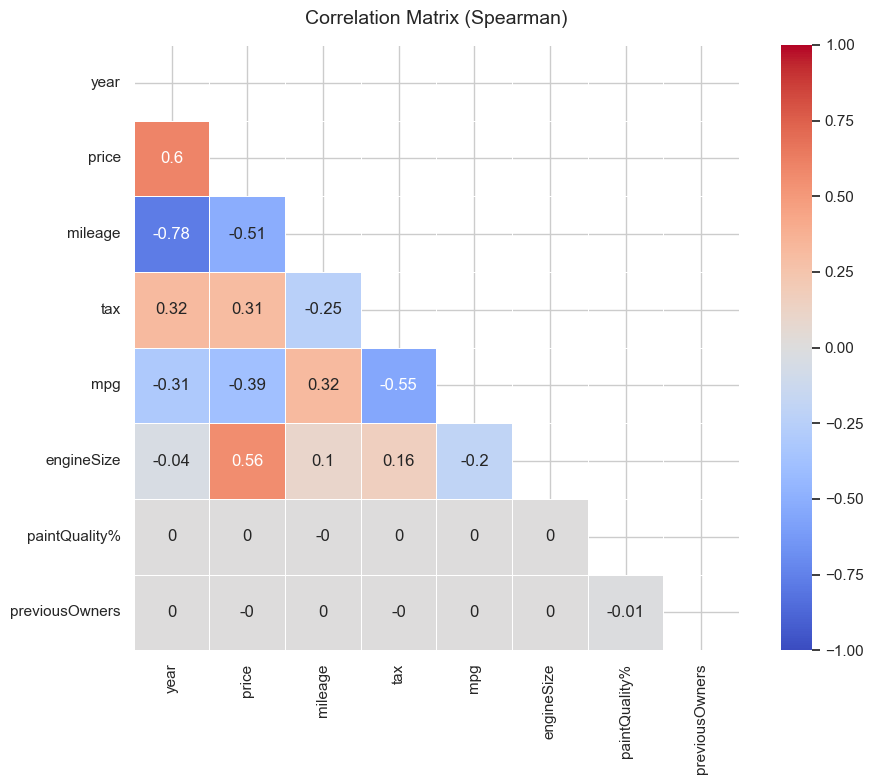

In [31]:
corr = train[metric_features].corr(method="spearman").round(2)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Visualize correlation matrix
fig = plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,                # hide upper triangle
    annot=True,               # show values
    cmap="coolwarm",          # divergent color map
    center=0,                 # center colormap in 0
    linewidths=0.5,           # lines between cells to help visualization
    vmin=-1, vmax=1,          # fix scale
    square=True               # make cells square-shaped
)


plt.title("Correlation Matrix (Spearman)", fontsize=14, pad=15)
plt.tight_layout() # improve layout by reducing overlaps
plt.show()

So from the correlation analysis with both spearman and pearson methods we can say that our model’s most important numerical predictors, for our target price, will likely be:
- year, mileage, engineSize
- tax and mpg might add secondary predictive power.
- paintQuality%, previousOwners, and hasDamage probably won’t help much unless cleaned or reinterpreted.

### Pairplot 

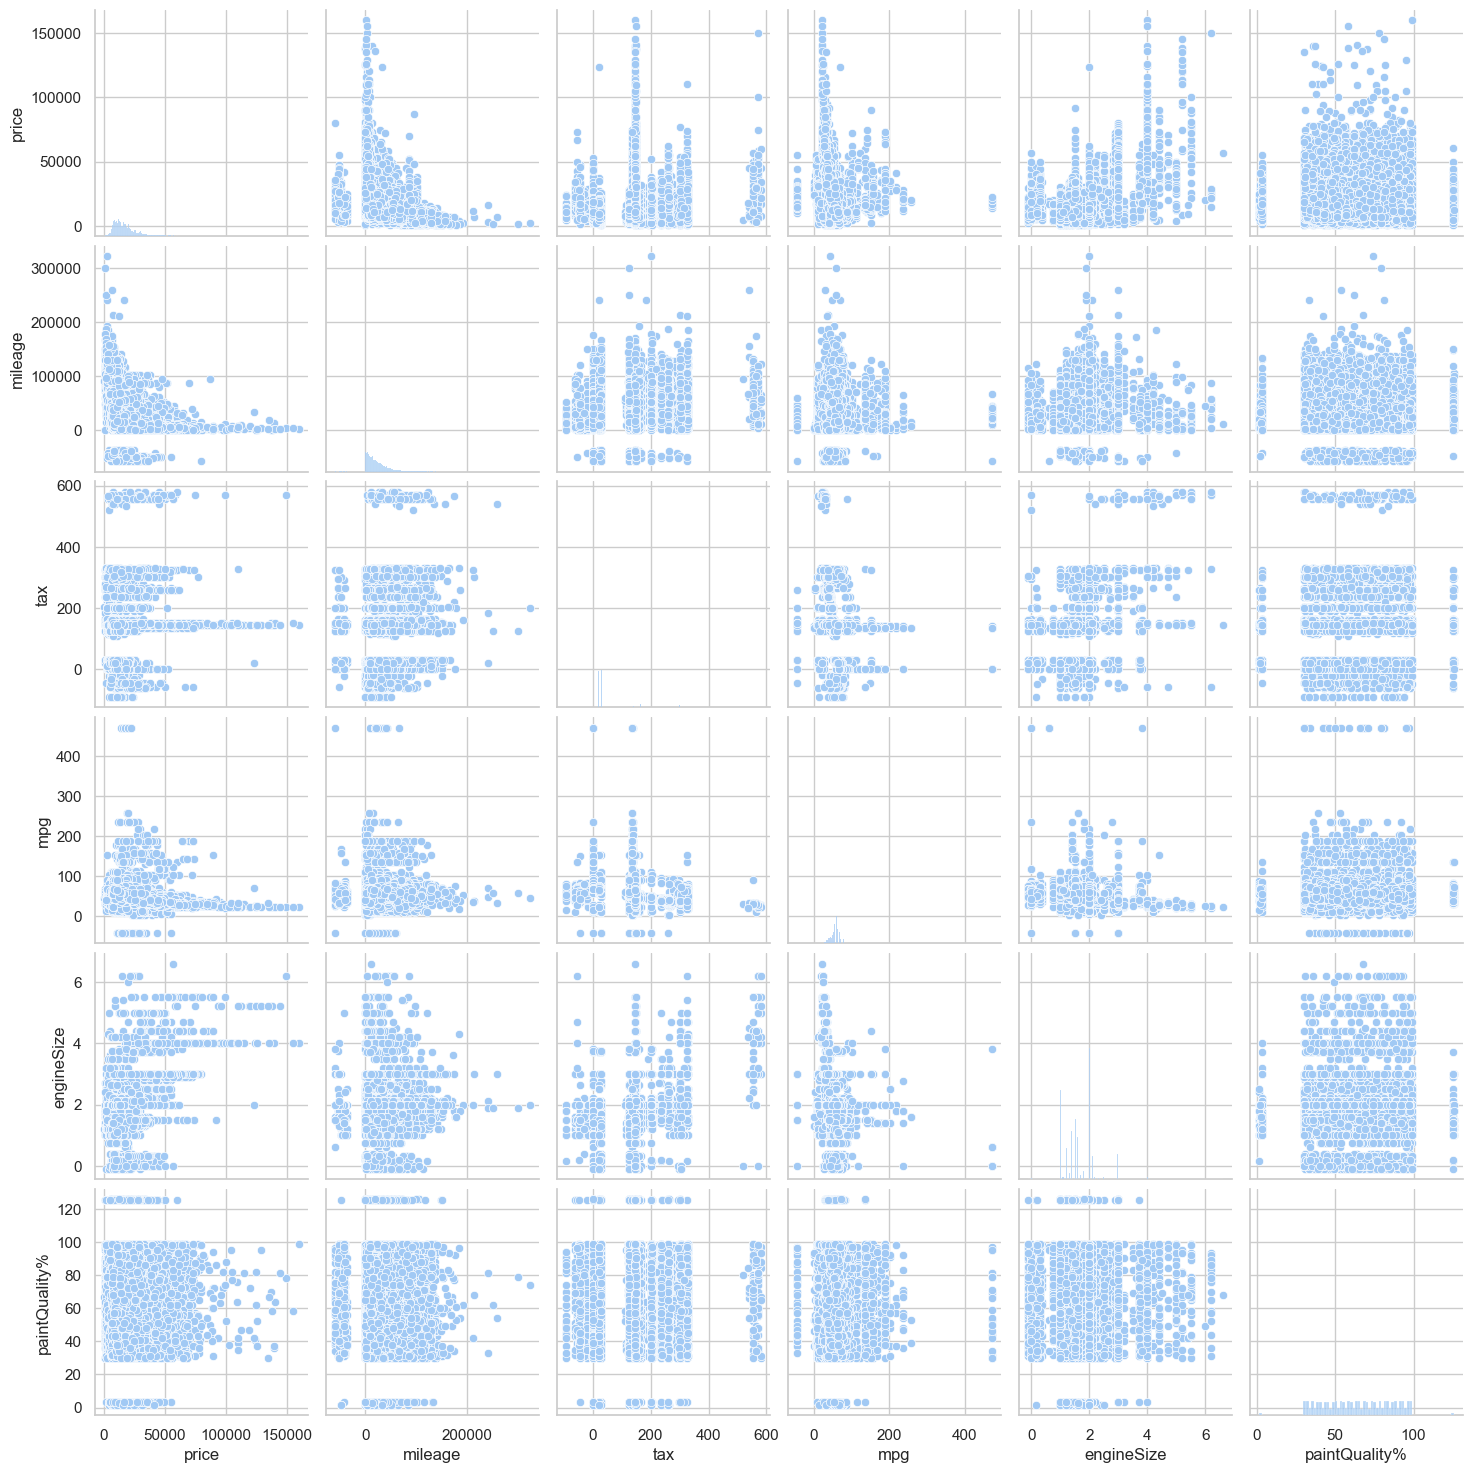

In [32]:
sns.pairplot(train[continuous_features])

## Multivariate Analysis

In this part, we explore the interactions between several features simultaneously. The goal is to identify more complex relationships and combined effects that may not be visible when analyzing features separately.

### 3D Scatterplot

The 3D scatter plot visualizes the relationship between a car’s price, year of registration, and mileage.
Each point represents a car, where newer models (higher year values) and those with lower mileage tend to have higher prices.
This graph helps identify depreciation patterns — as mileage increases or the car becomes older, its value generally decreases.
It provides a clear, three-dimensional view of how these features interact to influence car pricing.

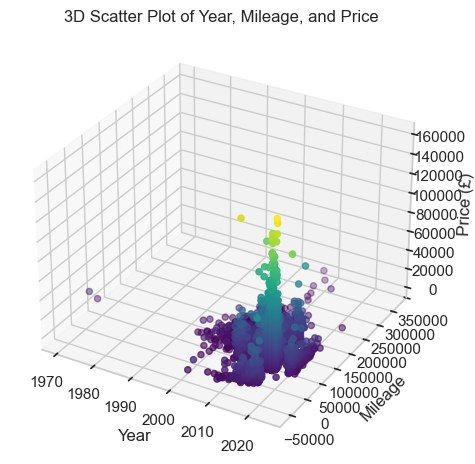

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(train['year'], train['mileage'], train['price'], c=train['price'], cmap='viridis')
ax.set_xlabel('Year')
ax.set_ylabel('Mileage')
ax.set_zlabel('Price (£)')

plt.title('3D Scatter Plot of Year, Mileage, and Price')
plt.tight_layout()
plt.show()


The three-dimensional analysis of Year, Mileage, and Price demonstrates that vehicle depreciation follows a cone shaped pattern, with recent models (2015-2023) and low mileage concentrated at the top of the price spectrum, while older vehicles converge toward a minimum value floor regardless of accumulated use. The pattern reveals three distinct depreciation dynamics: extreme sensitivity to mileage in recent vehicles, moderate depreciation in intermediate-age cars, and price stagnation in older models. Crucially, Year and Mileage do not act independently but through a multiplicative interaction, where the impact of mileage is amplified in newer cars and negligible in older ones, explaining the limitation of simple linear models and suggesting that interaction features and logarithmic transformations would be necessary to improve predictive accuracy, as well as investigation of outliers that indicate qualitative factors not captured by the model.

### Scatter Matrix

Illustrates the relationships between continuous features (price, year, mileage, engine size, and mpg) while distinguishing cars by fuel type.
Each scatter plot shows how two features interact, and the diagonal plots display their individual distributions.
From this visualization, we can identify patterns such as newer cars with lower mileage tending to have higher prices, or how fuel type influences fuel efficiency (mpg) and engine size.
Overall, the pairplot provides a comprehensive multivariate overview of how these core features relate to each other across different fuel categories.

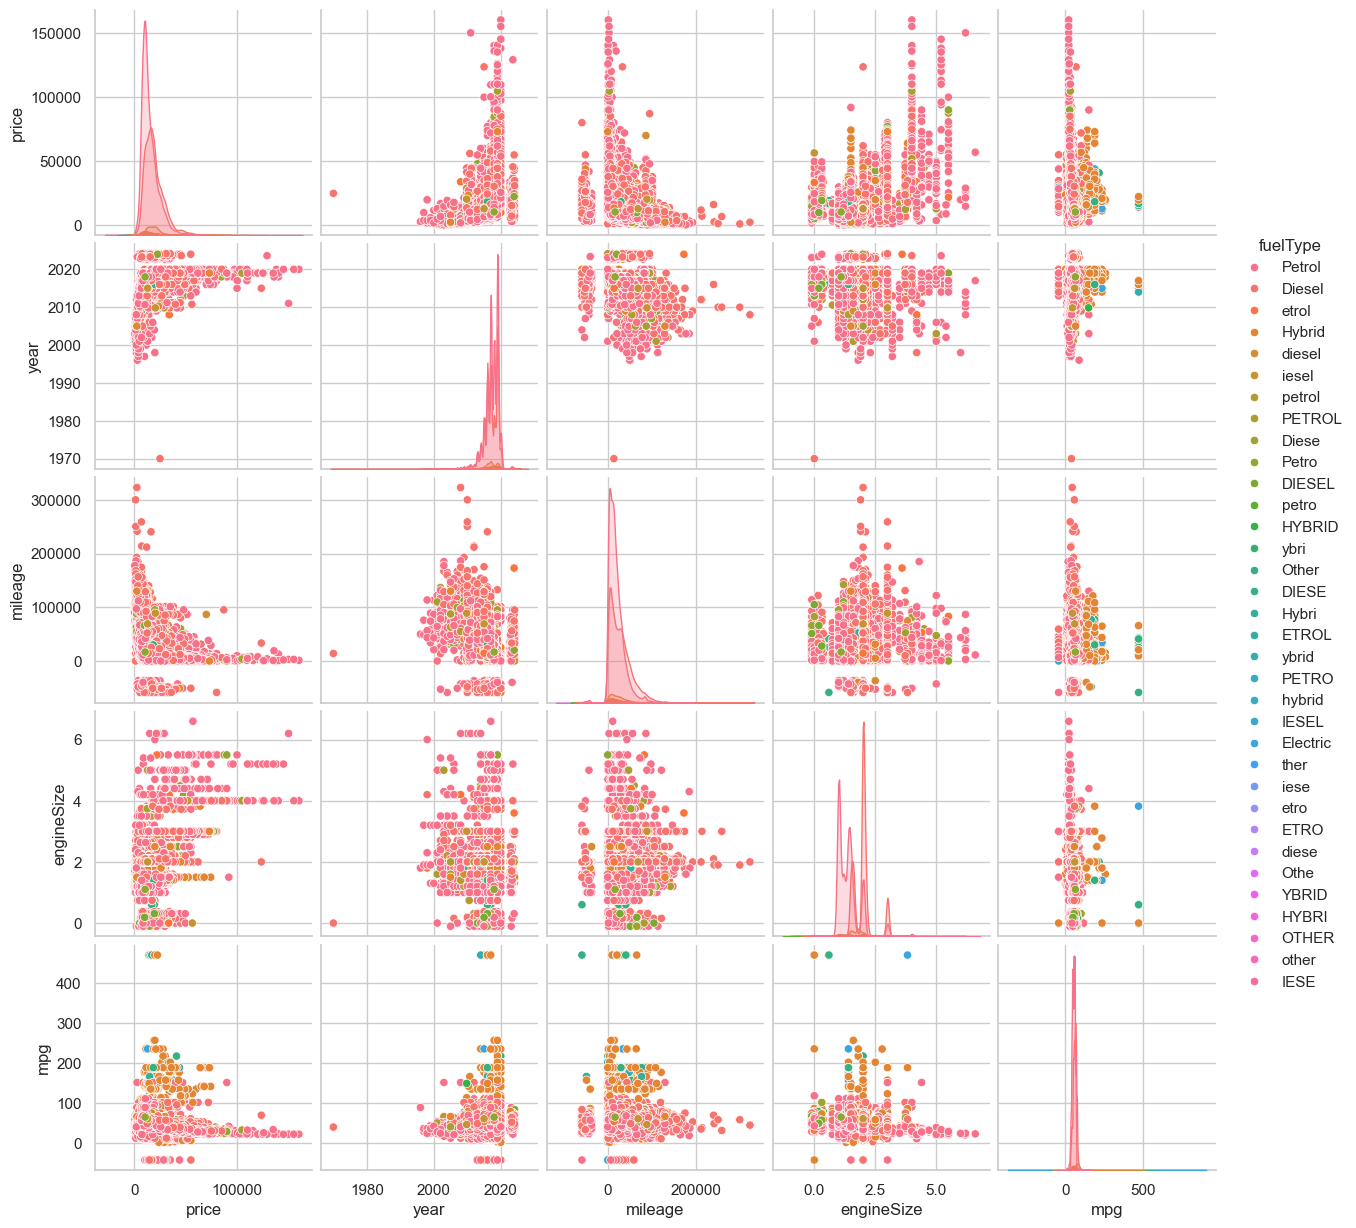

In [34]:
sns.pairplot(train, vars=['price', 'year', 'mileage', 'engineSize', 'mpg'], hue='fuelType')
plt.show()

The pairplot reveals strong relationships between vehicle price and features such as year, mileage, and engine size. It shows that newer cars with lower mileage tend to have higher prices, while vehicles with larger engines are generally more expensive but less fuel-efficient (lower mpg). There is also a clear negative correlation between engine size and fuel efficiency, indicating that bigger engines consume more fuel. The fuelType feature shows a predominance of petrol cars, although multiple variations in spelling suggest the need for data standardization. Overall, the dataset displays expected patterns of vehicle valuation but also contains outliers and inconsistencies that should be addressed for more accurate analysis.

## End of the Notebook

From our exploratory data analysis, we gained a better understanding of the different datasets. We observed key characteristics of the features, including distributions, ranges, and the presence of any outliers. The correlation analysis revealed some notable relationships between features, suggesting which features might be most relevant to the target. Based on these observations, we can form initial hypotheses about which features may influence the target and guide the next steps in feature selection and model building.